<a href="https://colab.research.google.com/github/Akshata4/parking_spot_detection/blob/main/parking_occupancy_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parking Spot Occupancy Detection
### MobileNetV2 fine-tuned binary classifier on PKLot dataset (Roboflow format)

**Sections:**
1. Install dependencies
2. Kaggle authentication and dataset download
3. Dataset exploration and visualisation
4. Data generators and augmentation
5. Build and train MobileNetV2
6. Evaluation
7. Inference demo
8. Save and export

> Set runtime to **GPU** (Runtime > Change runtime type > T4 GPU) before running.

---
## Section 1 - Install Dependencies

In [1]:
!pip install -q kaggle opencv-python-headless matplotlib seaborn scikit-learn tensorflow Pillow tqdm

In [2]:
import os, random, json
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow {tf.__version__}')
print('GPU:', tf.config.list_physical_devices('GPU') or 'None - switch runtime to GPU')


TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Section 2 - Kaggle Authentication and Dataset Download

1. Go to kaggle.com > Account > API > **Create New Token**
2. Upload the downloaded `kaggle.json` when prompted.


In [3]:
from google.colab import files

print('Upload your kaggle.json:')
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
with open(kaggle_path, 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod(kaggle_path, 0o600)
print('kaggle.json configured')


Upload your kaggle.json:


Saving kaggle.json to kaggle.json
kaggle.json configured


In [4]:
DATA_ROOT = Path('/content/pklot')
DATA_ROOT.mkdir(exist_ok=True)

print('Downloading PKLot dataset...')
!kaggle datasets download -d ammarnassanalhajali/pklot-dataset -p /content/pklot --unzip
print('Download complete')

# Show top-level structure
print('\nTop-level contents:')
for p in sorted(DATA_ROOT.iterdir()):
    print(' ', p.name)


Dataset URL: https://www.kaggle.com/datasets/ammarnassanalhajali/pklot-dataset
License(s): unknown
100% 843M/843M [00:05<00:00, 166MB/s]

Download complete

Top-level contents:
  README.dataset.txt
  README.roboflow.txt
  test
  train
  valid


In [5]:
# This Kaggle version is Roboflow format: train/valid/test with pre-cropped patches
# Structure: pklot/train/<class>/*.jpg

PKLOT_ROOT = DATA_ROOT
TRAIN_DIR  = PKLOT_ROOT / 'train'
VAL_DIR    = PKLOT_ROOT / 'valid'
TEST_DIR   = PKLOT_ROOT / 'test'

print('Dataset split summary:')
for split, directory in [('train', TRAIN_DIR), ('valid', VAL_DIR), ('test', TEST_DIR)]:
    if not directory.exists():
        print(f'  {split}: not found')
        continue
    for cls_dir in sorted(directory.iterdir()):
        if cls_dir.is_dir():
            n = len(list(cls_dir.glob('*.jpg')))
            print(f'  {split}/{cls_dir.name}: {n:,} images')


Dataset split summary:


---
## Section 3 - Dataset Exploration and Visualisation

In [6]:
# Class balance
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print('Classes:', classes)

counts = {cls: len(list((TRAIN_DIR / cls).glob('*.jpg'))) for cls in classes}
total  = sum(counts.values())
for cls, n in counts.items():
    print(f'  {cls}: {n:,} ({n/total*100:.1f}%)')


Classes: []


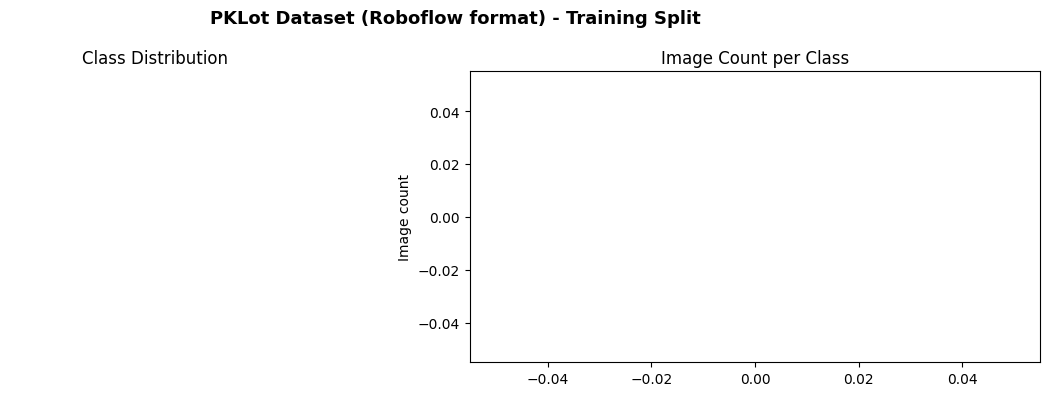

In [7]:
# Plot class balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PKLot Dataset (Roboflow format) - Training Split', fontsize=13, fontweight='bold')

colors = ['#e74c3c' if 'occ' in c.lower() else '#2ecc71' for c in classes]
ax1.pie(counts.values(), labels=counts.keys(), colors=colors,
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Class Distribution')

ax2.bar(counts.keys(), counts.values(), color=colors, width=0.5)
ax2.set_ylabel('Image count')
ax2.set_title('Image Count per Class')
for i, (cls, n) in enumerate(counts.items()):
    ax2.text(i, n + 50, f'{n:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
# Sample patches from each class
fig, axes = plt.subplots(len(classes), 8, figsize=(16, 3 * len(classes)))
if len(classes) == 1:
    axes = [axes]
fig.suptitle('Sample Patches per Class', fontsize=13, fontweight='bold')

for row, cls in enumerate(classes):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg'))
    sample = random.sample(imgs, min(8, len(imgs)))
    for col, img_path in enumerate(sample):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=10)

plt.tight_layout()
plt.show()


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x0 with 0 Axes>

---
## Section 4 - Data Generators and Augmentation

In [ ]:
IMG_SIZE   = (96, 96)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    brightness_range=[0.6, 1.4],
    zoom_range=0.1,
    horizontal_flip=True,
    shear_range=5,
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False)

CLASS_NAMES = {v: k for k, v in train_gen.class_indices.items()}
print('Class map:', CLASS_NAMES)
print(f'Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}')


In [ ]:
# Visualise augmented patches
batch_imgs, batch_labels = next(train_gen)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Augmented Training Patches', fontweight='bold')
for i in range(16):
    ax = axes[i // 8][i % 8]
    ax.imshow(batch_imgs[i])
    lbl = CLASS_NAMES[int(round(batch_labels[i]))]
    ax.set_title(lbl, fontsize=7,
                 color='#e74c3c' if 'occ' in lbl.lower() else '#2ecc71')
    ax.axis('off')
plt.tight_layout()
plt.show()


---
## Section 5 - Build and Train MobileNetV2

In [ ]:
def build_model(img_size=IMG_SIZE, lr=1e-4, unfreeze_top=30):
    base = MobileNetV2(input_shape=(*img_size, 3), include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers[:-unfreeze_top]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='ParkingMobileNetV2')
    model.compile(
        optimizer=Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')],
    )
    return model

model = build_model()
model.summary()


In [ ]:
CKPT_PATH = '/content/best_parking_model.keras'
EPOCHS    = 20

cb_list = [
    callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cb_list,
)
print('Training complete. Best model saved to:', CKPT_PATH)


In [ ]:
hist = history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')
for ax, metric, title in zip(
    axes,
    ['accuracy', 'loss', 'precision'],
    ['Accuracy', 'Loss', 'Precision']
):
    ax.plot(epochs_ran, hist[metric],          label='Train', linewidth=2)
    ax.plot(epochs_ran, hist[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section 6 - Evaluation

In [ ]:
model = tf.keras.models.load_model(CKPT_PATH)

val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_gen.classes

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print('=' * 40)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 40)
print()
occupied_idx = [v for k, v in train_gen.class_indices.items() if 'occ' in k.lower()]
label_names  = [k for k in sorted(train_gen.class_indices, key=train_gen.class_indices.get)]
print(classification_report(y_true, y_pred, target_names=label_names))


In [ ]:
cm = confusion_matrix(y_true, y_pred)
label_names = [k for k in sorted(train_gen.class_indices, key=train_gen.class_indices.get)]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  : {tn:,}')
print(f'False Positives : {fp:,}')
print(f'False Negatives : {fn:,}  <-- minimize (occupied predicted as empty)')
print(f'True Positives  : {tp:,}')


In [ ]:
# Show misclassified patches
all_val_files = [str(VAL_DIR / f) for f in val_gen.filenames]
fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]
fp_indices = np.where((y_true == 0) & (y_pred == 1))[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Misclassifications: Top=False Negatives | Bottom=False Positives', fontweight='bold')
for row, (indices, label) in enumerate([(fn_indices, 'FN'), (fp_indices, 'FP')]):
    if len(indices) == 0:
        for j in range(8): axes[row][j].axis('off')
        continue
    sample = np.random.choice(indices, min(8, len(indices)), replace=False)
    for j, idx in enumerate(sample):
        img = cv2.cvtColor(cv2.imread(all_val_files[idx]), cv2.COLOR_BGR2RGB)
        axes[row][j].imshow(img)
        axes[row][j].set_title(label, fontsize=8, color='red')
        axes[row][j].axis('off')
plt.tight_layout()
plt.show()


---
## Section 7 - Inference Demo

The Roboflow PKLot version contains pre-cropped patches, not full parking lot scenes,
so the inference demo runs on the held-out **test split** and shows predictions with confidence scores.
If you have a full scene image + XML annotation from the original PKLot dataset,
use the custom upload cell at the bottom.


In [ ]:
# Run inference on test split and display results in a grid
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False)

test_gen.reset()
y_test_probs = model.predict(test_gen, verbose=1)
y_test_pred  = (y_test_probs > 0.5).astype(int).flatten()
y_test_true  = test_gen.classes

test_acc = accuracy_score(y_test_true, y_test_pred)
print(f'Test set accuracy: {test_acc*100:.2f}%')


In [ ]:
# Display sample test predictions with confidence
all_test_files = [str(TEST_DIR / f) for f in test_gen.filenames]
sample_idx = random.sample(range(len(all_test_files)), 16)

fig, axes = plt.subplots(2, 8, figsize=(18, 6))
fig.suptitle('Test Set Predictions (green border = correct, red = wrong)', fontweight='bold')

for i, idx in enumerate(sample_idx):
    ax = axes[i // 8][i % 8]
    img = cv2.cvtColor(cv2.imread(all_test_files[idx]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    pred_label  = CLASS_NAMES[y_test_pred[idx]]
    true_label  = CLASS_NAMES[y_test_true[idx]]
    confidence  = y_test_probs[idx][0] if y_test_pred[idx] == 1 else 1 - y_test_probs[idx][0]
    correct     = y_test_pred[idx] == y_test_true[idx]

    border_color = '#2ecc71' if correct else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    ax.set_title(f'{pred_label}\n{confidence*100:.0f}%', fontsize=7,
                 color='#2ecc71' if correct else '#e74c3c')
    ax.axis('off')

plt.tight_layout()
plt.show()


### Occupancy Dashboard

In [ ]:
# Simulate per-scene occupancy by grouping test patches into batches of 20
# (mimics what a real parking lot scene would look like)
SCENE_SIZE = 20
n_scenes   = len(y_test_pred) // SCENE_SIZE

scene_stats = []
for i in range(n_scenes):
    batch_preds = y_test_pred[i*SCENE_SIZE:(i+1)*SCENE_SIZE]
    occ = int(batch_preds.sum())
    scene_stats.append({'scene': i, 'occupied': occ,
                        'empty': SCENE_SIZE - occ,
                        'pct': round(occ / SCENE_SIZE * 100, 1)})

df_dash = pd.DataFrame(scene_stats)
avg_pct = df_dash['pct'].mean()
print(f'Simulated {n_scenes} scenes of {SCENE_SIZE} spots each')
print(f'Average occupancy: {avg_pct:.1f}%')


In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Parking Occupancy Dashboard', fontsize=20,
             color='white', fontweight='bold', y=0.98)

def style_ax(ax):
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#2d3561')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.grid(color='#2d3561', linestyle='--', alpha=0.5)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.97, top=0.92, bottom=0.05)

# KPI row
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis('off')
kpis = [
    ('Total Spots', f"{df_dash['occupied'].sum() + df_dash['empty'].sum():,}", '#3498db'),
    ('Occupied',    f"{df_dash['occupied'].sum():,}",                          '#e74c3c'),
    ('Available',   f"{df_dash['empty'].sum():,}",                             '#2ecc71'),
    ('Avg Occ %',   f"{avg_pct:.1f}%",                                         '#f39c12'),
    ('Test Acc',    f"{test_acc*100:.1f}%",                                     '#9b59b6'),
]
for i, (label, val, color) in enumerate(kpis):
    x = 0.1 + i * 0.2
    kpi_ax.text(x, 0.75, val,   transform=kpi_ax.transAxes, fontsize=24,
                fontweight='bold', color=color, ha='center')
    kpi_ax.text(x, 0.2,  label, transform=kpi_ax.transAxes, fontsize=10,
                color='#aaaaaa', ha='center')

# Histogram of occupancy %
ax2 = fig.add_subplot(gs[1, 0]); style_ax(ax2)
ax2.hist(df_dash['pct'], bins=20, color='#3498db', edgecolor='none', alpha=0.8)
ax2.axvline(avg_pct, color='#f39c12', linestyle='--', linewidth=2,
            label=f'Mean {avg_pct:.1f}%')
ax2.set_title('Occupancy % Distribution')
ax2.set_xlabel('Occupancy %'); ax2.set_ylabel('Scene count')
ax2.legend(facecolor='#16213e', labelcolor='white')

# Occupied vs empty total
ax3 = fig.add_subplot(gs[1, 1]); style_ax(ax3)
totals = [df_dash['occupied'].sum(), df_dash['empty'].sum()]
ax3.bar(['Occupied', 'Available'], totals, color=['#e74c3c', '#2ecc71'], width=0.5)
ax3.set_title('Total Spots Across All Scenes')
ax3.set_ylabel('Count')
for i, v in enumerate(totals):
    ax3.text(i, v + 10, f'{v:,}', ha='center', color='white', fontweight='bold')

# Model metrics
ax4 = fig.add_subplot(gs[1, 2]); style_ax(ax4)
bars = ax4.barh(['Accuracy', 'Precision', 'Recall', 'F1'],
                [acc, prec, rec, f1],
                color=['#3498db', '#9b59b6', '#2ecc71', '#f39c12'])
ax4.set_xlim(0, 1.1)
ax4.set_title('Model Performance (Val Set)')
for bar, val in zip(bars, [acc, prec, rec, f1]):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', color='white', fontsize=9)

# Per-scene occupancy line
ax5 = fig.add_subplot(gs[2, :]); style_ax(ax5)
ax5.plot(df_dash['scene'], df_dash['pct'], color='#3498db', linewidth=1.5, alpha=0.8)
ax5.fill_between(df_dash['scene'], df_dash['pct'], alpha=0.2, color='#3498db')
ax5.axhline(avg_pct, color='#f39c12', linestyle='--',
            linewidth=2, label=f'Mean {avg_pct:.1f}%')
ax5.set_title('Per-Scene Occupancy %')
ax5.set_xlabel('Scene index'); ax5.set_ylabel('Occupancy %')
ax5.set_ylim(0, 105)
ax5.legend(facecolor='#16213e', labelcolor='white')

plt.show()


### Upload Your Own Patch Image

In [ ]:
# Upload any parking spot patch image for a single prediction
from google.colab import files as colab_files

print('Upload a parking spot image (.jpg or .png):')
uploaded_img = colab_files.upload()

for fname, data in uploaded_img.items():
    img_array = np.frombuffer(data, dtype=np.uint8)
    img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_bgr, IMG_SIZE)
    patch = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)

    prob = model.predict(patch, verbose=0)[0][0]
    # Determine which index is 'occupied'
    occ_idx = train_gen.class_indices.get('occupied',
              train_gen.class_indices.get('Occupied', 1))
    pred_idx  = 1 if prob > 0.5 else 0
    label     = CLASS_NAMES[pred_idx]
    confidence = prob if pred_idx == 1 else 1 - prob

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f'Prediction: {label}\nConfidence: {confidence*100:.1f}%',
              fontsize=13, fontweight='bold',
              color='#e74c3c' if 'occ' in label.lower() else '#2ecc71')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


---
## Section 8 - Save and Export

In [ ]:
model.save('/content/parking_model_final.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/parking_model.tflite', 'wb') as f:
    f.write(tflite_model)

config = {
    'class_indices': train_gen.class_indices,
    'img_size': IMG_SIZE,
    'metrics': {
        'accuracy':  round(float(acc),  4),
        'precision': round(float(prec), 4),
        'recall':    round(float(rec),  4),
        'f1':        round(float(f1),   4),
    }
}
with open('/content/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved:')
print('  /content/parking_model_final.keras')
print('  /content/parking_model.tflite')
print('  /content/model_config.json')


In [ ]:
from google.colab import files as colab_files
for p in ['/content/parking_model_final.keras',
           '/content/parking_model.tflite',
           '/content/model_config.json']:
    colab_files.download(p)
print('All files downloaded.')


---
## Summary

| Step | Detail |
|------|--------|
| Dataset | PKLot via Kaggle (Roboflow format: train/valid/test pre-cropped patches) |
| Augmentation | Brightness, rotation, zoom, flip to simulate weather variation |
| Model | MobileNetV2 fine-tuned (top 30 layers unfrozen), binary sigmoid head |
| Training | EarlyStopping + ReduceLROnPlateau, best checkpoint saved |
| Evaluation | Accuracy, Precision, Recall, F1, confusion matrix |
| Inference | Test split predictions with confidence + occupancy dashboard |
| Export | .keras, .tflite (quantised), model_config.json |

**Recall for the occupied class is prioritised** - a false negative (occupied spot predicted as empty) is the worst user experience.
